# KNN Assignment

## Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.feature_selection import f_classif
from svm_margin_plot import plot_svm_boundary
import time
import warnings
warnings.filterwarnings('ignore')

## Preprocessing and EDA

In [2]:
data = pd.read_csv("/content/CAR_EVALUATION.csv")

In [3]:
data.head(10)

,buying,maint,doors,persons,lug_boot,safety,Target
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   Target    1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [5]:
data.describe()

,buying,maint,doors,persons,lug_boot,safety,Target
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [6]:
for col in data.columns:
  print(f"{data[col].value_counts()}")
  print("----"*20)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
--------------------------------------------------------------------------------
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
--------------------------------------------------------------------------------
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
--------------------------------------------------------------------------------
persons
2       576
4       576
more    576
Name: count, dtype: int64
--------------------------------------------------------------------------------
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
--------------------------------------------------------------------------------
safety
low     576
med     576
high    576
Name: count, dtype: int64
--------------------------------------------------------------------------------
Target
unacc    1210
acc       384
good       69

In [7]:
data.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
Target,0


In [8]:
data.duplicated().sum()

np.int64(0)

## Train Test Validation Split

In [9]:
X = data.drop(["Target"], axis=1)
y = data[["Target"]]

In [10]:
X1 , X_test, y1, y_test = train_test_split(X,y, test_size=0.2476, random_state=42, shuffle=True, stratify=y)
X_train , X_val, y_train, y_val = train_test_split(X1,y1, test_size=0.23076, random_state=42, shuffle=True, stratify=y1)

print("Length of Data")

print("----"*20)

print("Training data")
print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")

print("----"*20)

print("Validataion data")
print(f"X_val: {len(X_val)}")
print(f"y_val: {len(y_val)}")

print("----"*20)

print("Testing data")
print(f"X_test: {len(X_test)}")
print(f"y_test: {len(y_test)}")


Length of Data
--------------------------------------------------------------------------------
Training data
X_train: 1000
y_train: 1000
--------------------------------------------------------------------------------
Validataion data
X_val: 300
y_val: 300
--------------------------------------------------------------------------------
Testing data
X_test: 428
y_test: 428


## Labeling Ordinal Data

In [11]:
for indx in data.columns:
  print(f"{indx}")
  print("----"*20)

buying
--------------------------------------------------------------------------------
maint
--------------------------------------------------------------------------------
doors
--------------------------------------------------------------------------------
persons
--------------------------------------------------------------------------------
lug_boot
--------------------------------------------------------------------------------
safety
--------------------------------------------------------------------------------
Target
--------------------------------------------------------------------------------


In [12]:
for col in data.columns:
  print(f"{data[col].value_counts()}")
  print("----"*20)

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
--------------------------------------------------------------------------------
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
--------------------------------------------------------------------------------
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
--------------------------------------------------------------------------------
persons
2       576
4       576
more    576
Name: count, dtype: int64
--------------------------------------------------------------------------------
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
--------------------------------------------------------------------------------
safety
low     576
med     576
high    576
Name: count, dtype: int64
--------------------------------------------------------------------------------
Target
unacc    1210
acc       384
good       69

In [13]:
buying_order = ['low', 'med', 'high', "vhigh"]
maint_order = ['low', 'med', 'high', "vhigh"]
doors_order = ['2', '3', '4', '5more']
persons_order = ['2', '4', 'more']
lug_boot_order = ['small', 'med', 'big']
safety_order = ['low', 'med', 'high']

ordinal_features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

categories = [buying_order, maint_order, doors_order, persons_order, lug_boot_order, safety_order]


In [14]:
oe = OrdinalEncoder(categories=categories)

In [15]:
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()


X_train_encoded[ordinal_features] = oe.fit_transform(X_train_encoded[ordinal_features])
X_val_encoded[ordinal_features] = oe.transform(X_val_encoded[ordinal_features])
X_test_encoded[ordinal_features] = oe.transform(X_test_encoded[ordinal_features])


In [16]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
174,vhigh,high,4,4,med,low
1272,med,low,5more,2,med,low
657,high,med,2,4,small,low
1645,low,low,2,more,big,med
1037,med,high,4,4,small,high


In [17]:
X_train_encoded.head()

,buying,maint,doors,persons,lug_boot,safety
174,3.0,2.0,2.0,1.0,1.0,0.0
1272,1.0,0.0,3.0,0.0,1.0,0.0
657,2.0,1.0,0.0,1.0,0.0,0.0
1645,0.0,0.0,0.0,2.0,2.0,1.0
1037,1.0,2.0,2.0,1.0,0.0,2.0


In [18]:
Target_orders = ['unacc', 'acc', 'good', 'vgood']
oe = OrdinalEncoder(categories=[Target_orders])

In [19]:
y_train_encoded = y_train.copy()
y_val_encoded = y_val.copy()
y_test_encoded = y_test.copy()

y_train_label = oe.fit_transform(y_train_encoded[['Target']])
y_val_label = oe.transform(y_val_encoded[['Target']])
y_test_label = oe.transform(y_test_encoded[['Target']])

In [20]:
y_train_label = pd.DataFrame(y_train_label, columns=oe.get_feature_names_out())

y_val_label = pd.DataFrame(y_val_label, columns=oe.get_feature_names_out())

y_test_label = pd.DataFrame(y_test_label, columns=oe.get_feature_names_out())

In [21]:
y_train_label.head()

,Target
0,0.0
1,0.0
2,0.0
3,2.0
4,1.0


## Trying to test the KNN model and other models

In [22]:
KNN = KNeighborsClassifier(n_neighbors=8)

In [23]:
KNN.fit(X_train_encoded, y_train_label)

KNeighborsClassifier(n_neighbors=8)

In [24]:
y_pred = KNN.predict(X_test_encoded)

In [25]:
print(classification_report(y_pred=y_pred, y_true=y_test_label))

              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95       300
         1.0       0.89      0.78      0.83        95
         2.0       0.83      0.59      0.69        17
         3.0       1.00      0.69      0.81        16

    accuracy                           0.92       428
   macro avg       0.91      0.76      0.82       428
weighted avg       0.91      0.92      0.91       428



In [26]:
params={
    'C' :[0.01,0.1,1,10],
    'gamma':[0.01,0.1,1,10]
}

In [27]:
svm = SVC(kernel='rbf')

In [28]:
grid = GridSearchCV(svm,params)

In [29]:
grid.fit(X_train_encoded,y_train_label)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': [0.01, 0.1, 1, 10]})

In [30]:
grid.best_estimator_

SVC(C=10, gamma=0.1)

In [31]:
best_model = SVC(kernel='rbf', C=10, gamma=0.1)
best_model.fit(X_train_encoded, y_train_label)

SVC(C=10, gamma=0.1)

In [32]:
y_pred = best_model.predict(X_test_encoded)

In [33]:
accuracy_score(y_pred=y_pred, y_true=y_test_label)

0.969626168224299

In [34]:
print(classification_report(y_pred=y_pred, y_true=y_test_label))

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       300
         1.0       0.93      0.94      0.93        95
         2.0       0.94      0.94      0.94        17
         3.0       1.00      0.94      0.97        16

    accuracy                           0.97       428
   macro avg       0.96      0.95      0.96       428
weighted avg       0.97      0.97      0.97       428



## Dividing Training set into 10 sets

In [35]:
models = []

for i in range(10):
  KNN = KNeighborsClassifier(n_neighbors=2)
  models.append(KNN)

In [36]:
models

[KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2),
 KNeighborsClassifier(n_neighbors=2)]

In [37]:
# for i in range(10):
#   X_train_temp = X_train_encoded[: int(len(X_train_encoded) * (i+1) * 0.1)]
#   y_train_temp = y_train_label[: int(len(y_train_label) * (i+1) * 0.1)]
#   models[i].fit(X_train_temp, y_train_temp)


In [38]:
# val_acc_scores = []
# test_acc_scores = []

# for i in range(10):
#   y_pred_val_temp = models[i].predict(X_val_encoded)
#   val_acc_scores.append(accuracy_score(y_pred=y_pred_val_temp, y_true=y_val_label))

#   y_pred_test_temp = models[i].predict(X_test_encoded)
#   test_acc_scores.append(accuracy_score(y_pred=y_pred_test_temp, y_true=y_test_label))



In [39]:
# for i in range(10):
#   print(f'"model[{i}] accuracy scores"')
#   print(f"val_acc_score: {val_acc_scores[i] * 100}% | test_acc_score: {test_acc_scores[i] * 100}%")
#   print("----"*20)

In [40]:
val_acc_scores = []
test_acc_scores = []
models = []

for i in range(10):
  KNN = KNeighborsClassifier(n_neighbors=2)
  models.append(KNN)

  X_train_temp = X_train_encoded[: int(len(X_train_encoded) * (i+1) * 0.1)]
  y_train_temp = y_train_label[: int(len(y_train_label) * (i+1) * 0.1)]

  models[i].fit(X_train_temp, y_train_temp)
  y_pred_val_temp = models[i].predict(X_val_encoded)
  val_acc_scores.append(accuracy_score(y_pred=y_pred_val_temp, y_true=y_val_label) * 100)

  y_pred_test_temp = models[i].predict(X_test_encoded)
  test_acc_scores.append(accuracy_score(y_pred=y_pred_test_temp, y_true=y_test_label) * 100)

  print(f'"model[{i}] accuracy scores"')
  print(f"val_acc_score: {val_acc_scores[i]}% | test_acc_score: {test_acc_scores[i]}%")
  print("----"*20)

"model[0] accuracy scores"
val_acc_score: 79.66666666666666% | test_acc_score: 81.54205607476635%
--------------------------------------------------------------------------------
"model[1] accuracy scores"
val_acc_score: 83.66666666666667% | test_acc_score: 84.57943925233646%
--------------------------------------------------------------------------------
"model[2] accuracy scores"
val_acc_score: 85.0% | test_acc_score: 84.57943925233646%
--------------------------------------------------------------------------------
"model[3] accuracy scores"
val_acc_score: 86.66666666666667% | test_acc_score: 85.2803738317757%
--------------------------------------------------------------------------------
"model[4] accuracy scores"
val_acc_score: 86.66666666666667% | test_acc_score: 85.51401869158879%
--------------------------------------------------------------------------------
"model[5] accuracy scores"
val_acc_score: 85.0% | test_acc_score: 84.57943925233646%
----------------------------------

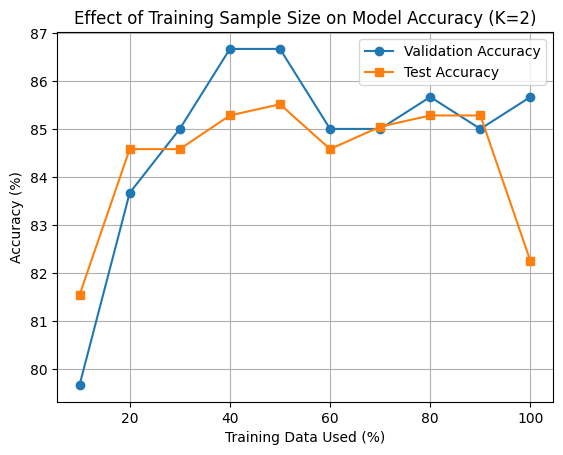

In [41]:
x_axis = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

plt.plot(x_axis, val_acc_scores, marker='o', label='Validation Accuracy')
plt.plot(x_axis, test_acc_scores, marker='s', label='Test Accuracy')

plt.title('Effect of Training Sample Size on Model Accuracy (K=2)')
plt.xlabel('Training Data Used (%)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

## Estimating best K

In [42]:
scores = []
for i in range(1,11):
  KNN = KNeighborsClassifier(n_neighbors=i)
  score =  cross_val_score(KNN, X_train_encoded, y_train_label, cv=5).mean()
  scores.append(score*100)

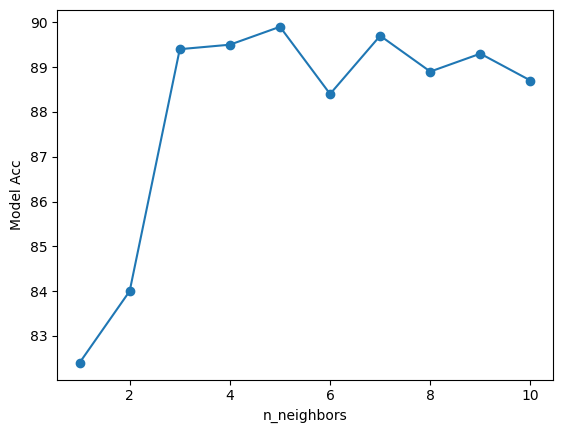

In [43]:
plt.plot(range(1,11), scores, marker='o')
plt.xlabel('n_neighbors')
plt.ylabel('Model Acc')
plt.show()

In [44]:
# From the plot the best K value is equal 5

## Scenarios

In [45]:
scenarios = {
    "Case 1\n10% data, K=2": {"n_neighbors" : 2, "fraction": 0.1},
    "Case 2\n100% data, K=2": {"n_neighbors" : 2, "fraction": 1.0},
    "Case 3\n10% data, K=10": {"n_neighbors" : 10, "fraction": 0.1},
    "Case 4\n100% data, K=10": {"n_neighbors" : 10, "fraction": 1.0}
}

In [46]:
train_times = []
predict_times = []

for case, params in scenarios.items():
    n_samples = int(len(X_train_encoded) * params["fraction"])
    X_sub, y_sub = X_train_encoded[:n_samples], y_train_label[:n_samples]

    model = KNeighborsClassifier(n_neighbors=params["n_neighbors"])

    start = time.time()
    model.fit(X_sub, y_sub)
    end = time.time()
    train_time = end - start

    start = time.time()
    _ = model.predict(X_val_encoded)
    end = time.time()
    predict_time = end - start

    train_times.append(train_time)
    predict_times.append(predict_time)


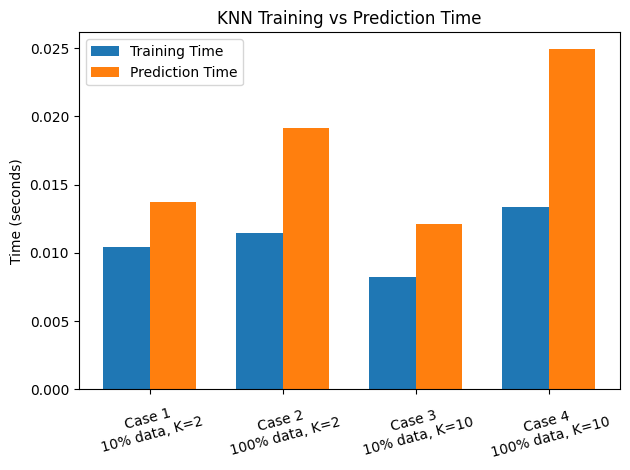

In [47]:
x = np.arange(len(scenarios))
width = 0.35

plt.bar(x - width/2, train_times, width, label="Training Time")
plt.bar(x + width/2, predict_times, width, label="Prediction Time")

plt.xticks(x, scenarios.keys(), rotation=15)
plt.ylabel("Time (seconds)")
plt.title("KNN Training vs Prediction Time")
plt.legend()
plt.tight_layout()
plt.show()


## Conlusion

* More training data → higher and more stable accuracy.

* Best K = 5 achieved optimal performance on the validation set.

* Prediction time grows with both dataset size and K value.